# heatmap
> Similarity, matrix, and confusion plots split from `08_all.ipynb`.

In [ ]:
#| default_exp heatmap

In [ ]:
#| export
import warnings

import numpy as np
import pandas as pd
import seaborn as sns
from matplotlib import pyplot as plt
from sklearn.metrics import confusion_matrix, pairwise_distances

In [ ]:
df = sns.load_dataset('titanic').dropna(subset=['age', 'fare', 'class', 'sex', 'survived']).reset_index(drop=True)
df2 = df[['age', 'fare', 'sibsp', 'parch']].head(8).copy()
df2.index = [f'row_{i}' for i in range(len(df2))]
print(df.shape)
print(df2.shape)

(714, 15)
(8, 4)


In [ ]:
df.head()

,survived,pclass,sex,age,sibsp,parch,fare,embarked,class,who,adult_male,deck,embark_town,alive,alone
0,0,3,male,22.0,1,0,7.2500,S,Third,man,True,NaN,Southampton,no,False
1,1,1,female,38.0,1,0,71.2833,C,First,woman,False,C,Cherbourg,yes,False
2,1,3,female,26.0,0,0,7.9250,S,Third,woman,False,NaN,Southampton,yes,True
3,1,1,female,35.0,1,0,53.1000,S,First,woman,False,C,Southampton,yes,False
4,0,3,male,35.0,0,0,8.0500,S,Third,man,True,NaN,Southampton,no,True


## Matrix Helpers

In [ ]:
#| export
def get_similarity(
    df: pd.DataFrame,  # numeric feature matrix indexed by sample name
    metric: str = 'euclidean',  # pairwise_distances metric name
) -> tuple[pd.DataFrame, pd.DataFrame]:
    "Calculate both distance and similarity matrices for a dataframe."
    dist_matrix = pairwise_distances(df, metric=metric)
    dist_df = pd.DataFrame(dist_matrix, index=df.index, columns=df.index)
    sigma = float(np.mean(dist_matrix))
    if not np.isfinite(sigma) or np.isclose(sigma, 0.0):
        sim_df = pd.DataFrame(np.ones_like(dist_matrix, dtype=float), index=df.index, columns=df.index)
    else:
        sim_df = pd.DataFrame(np.exp(-(dist_matrix ** 2) / (2 * sigma ** 2)), index=df.index, columns=df.index)
    return dist_df, sim_df

In [ ]:
get_similarity(df2)[0]

,row_0,row_1,row_2,row_3,row_4,row_5,row_6,row_7
row_0,0.000000,66.001996,4.177993,47.657345,13.062925,54.911521,24.415786,6.714166
row_1,66.001996,0.000000,64.492435,18.429118,63.312323,25.182682,61.821302,61.188418
row_2,4.177993,64.492435,0.000000,46.073643,9.000868,52.100901,27.548548,3.910651
row_3,47.657345,18.429118,46.073643,0.000000,45.061097,19.066500,46.039121,42.780883
row_4,13.062925,63.312323,9.000868,45.061097,0.000000,47.754949,35.618122,8.803791
row_5,54.911521,25.182682,52.100901,19.066500,47.754949,0.000000,60.513388,48.906725
row_6,24.415786,61.821302,27.548548,46.039121,35.618122,60.513388,0.000000,27.089433
row_7,6.714166,61.188418,3.910651,42.780883,8.803791,48.906725,27.089433,0.000000


In [ ]:
#| export
def plot_corr(
    df_corr: pd.DataFrame,  # correlation, distance, or similarity matrix
    mask_method: str | None = 'upper',  # upper, lower, or None
    inverse_color: bool = False,  # reverse the colormap when True
    figsize: tuple[float, float] = (15, 10),  # figure size in inches
    annot: bool = True,  # whether to annotate the matrix values
    linewidths: float = 0.1,  # cell border width
    **kwargs,  # forwarded heatmap kwargs
):
    "Plot a square matrix with an optional triangular mask." 
    if mask_method == 'upper':
        mask = np.triu(np.ones_like(df_corr, dtype=bool))
    elif mask_method == 'lower':
        mask = np.tril(np.ones_like(df_corr, dtype=bool))
    else:
        mask = None

    fig, ax = plt.subplots(figsize=figsize)
    sns.heatmap(
        df_corr,
        cmap='coolwarm_r' if inverse_color else 'coolwarm',
        mask=mask,
        annot=annot,
        fmt='.2f',
        linewidths=linewidths,
        linecolor='white',
        ax=ax,
        **kwargs,
    )
    ax.set_xlabel('')
    ax.set_ylabel('')
    plt.yticks(rotation=0)
    return ax

<Axes: >

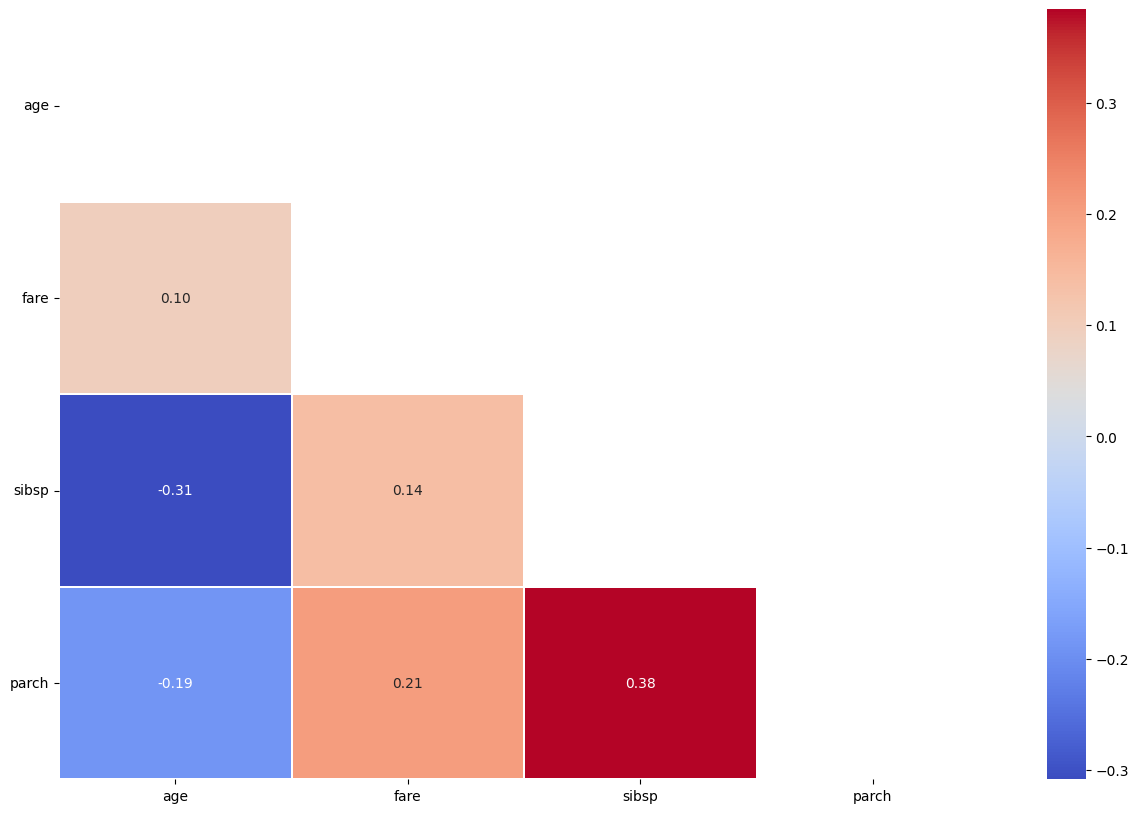

In [ ]:
plot_corr(df[['age', 'fare', 'sibsp', 'parch']].corr(numeric_only=True))

## Classification And Composition

In [ ]:
#| export
def plot_confusion_matrix(
    target,  # true labels
    pred,  # predicted labels
    class_names: list[str] | None = None,  # labels shown on the axes
    normalize: bool = False,  # normalize rows when True
    title: str = 'Confusion matrix',  # plot title
    cmap=plt.cm.Blues,  # matplotlib colormap
    **kwargs,  # forwarded heatmap kwargs
):
    "Plot a confusion matrix from target and prediction arrays."
    observed_labels = pd.Index(pd.concat([pd.Series(target), pd.Series(pred)], ignore_index=True).dropna().unique()).tolist()
    if len(observed_labels) == 0:
        raise ValueError('target and pred must contain at least one non-null label')

    with warnings.catch_warnings():
        warnings.filterwarnings("ignore", message=r"A single label was found in 'y_true' and 'y_pred'.*", category=UserWarning)
        cm = confusion_matrix(target, pred, labels=observed_labels)
    if normalize:
        row_sums = cm.sum(axis=1, keepdims=True)
        cm = np.divide(cm.astype(float), row_sums, out=np.zeros_like(cm, dtype=float), where=row_sums != 0)
        print('Normalized confusion matrix')
    else:
        print('Confusion matrix, without normalization')

    if class_names is None or len(class_names) != len(observed_labels):
        class_names = [str(label) for label in observed_labels]

    fig, ax = plt.subplots(figsize=(6, 6))
    sns.heatmap(cm, annot=True, fmt='.2f' if normalize else 'd', cmap=cmap, ax=ax, **kwargs)
    ax.set_title(title)
    ax.set_ylabel('True label')
    ax.set_xlabel('Predicted label')
    ax.set_xticks(np.arange(len(class_names)) + 0.5, class_names)
    ax.set_yticks(np.arange(len(class_names)) + 0.5, class_names)
    plt.yticks(rotation=0)
    return ax

Normalized confusion matrix


<Axes: title={'center': 'Confusion matrix'}, xlabel='Predicted label', ylabel='True label'>

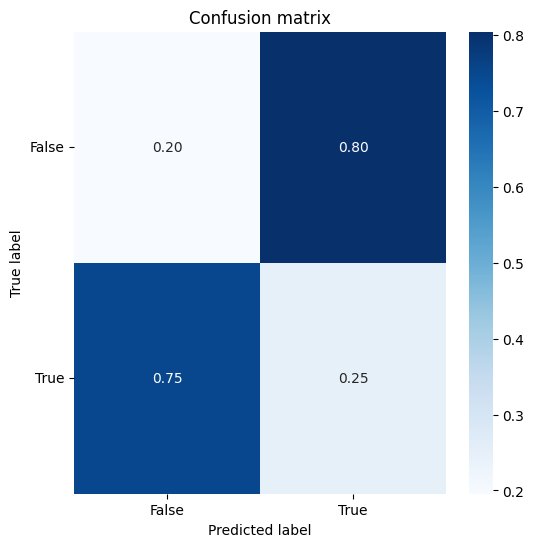

In [ ]:
plot_confusion_matrix(df['survived'], df['adult_male'], class_names=['False', 'True'], normalize=True)

## Export -

In [ ]:
#| hide
import nbdev; nbdev.nbdev_export()